<a href="https://colab.research.google.com/github/ilsagandeguay/PCVK-Ganjil-2026/blob/main/Week02._Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D1 Pengenalan Phyton: Pengolahan Citra Dasar dan memahami channel warna pada OpenCV dan konversinya

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KTM.png to KTM.png


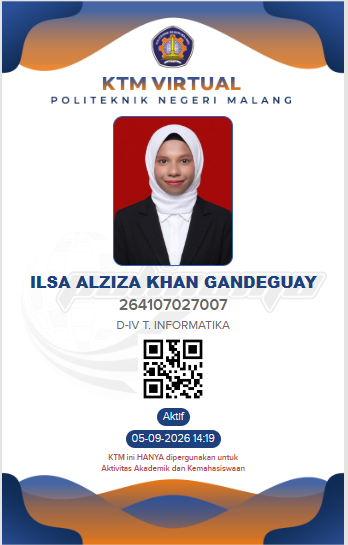

Resolusi gambar  348 x 545


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('KTM.png')
cv2_imshow(img)
img2 = cv.imread('/content/drive/MyDrive/Politeknik Negeri Malang/Matakuliah/Pengenalan Citra dan Visi Komputer/Week2/img2.jpg')

print("Resolusi gambar ", img.shape[1], "x", img.shape[0])

Menampilkan Gambar

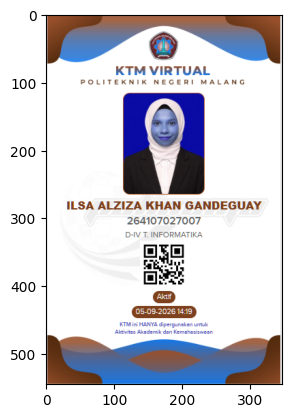

In [ ]:
img = cv.imread('KTM.png')
plt.imshow(img)

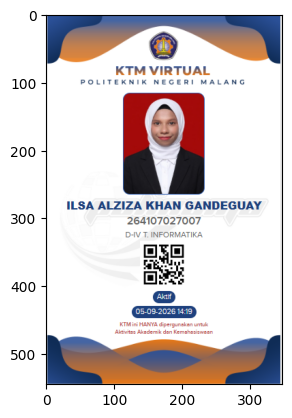

In [ ]:
img2 = cv.cvtColor(img,cv.COLOR_BGR2RGB)
plt.imshow(img2)

Menampilkan citra greyscale

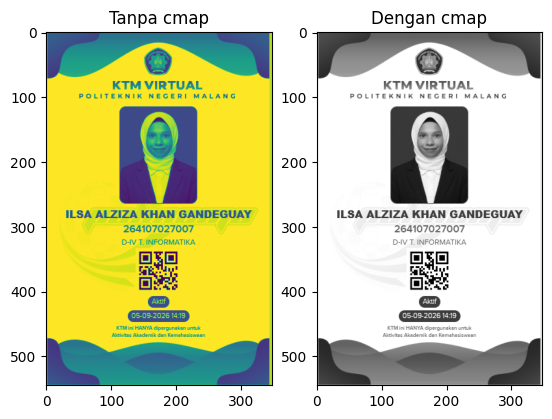

In [ ]:
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

#dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

Melakukan resizing


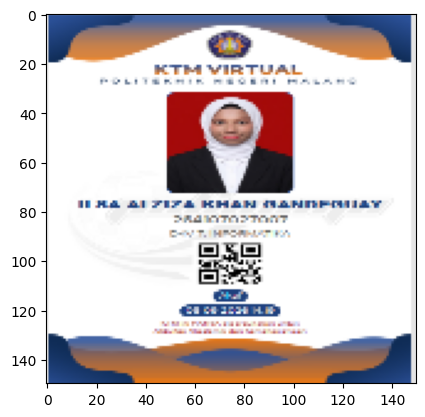

In [ ]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_output = cv.resize(imgRGB, (150,150))

plt.imshow(img_output)
#

Melakukan flipping

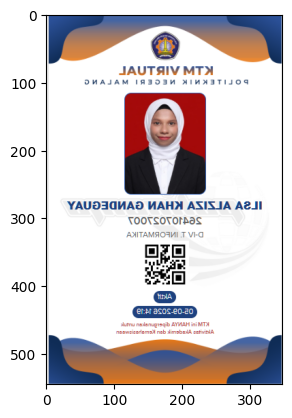

In [ ]:
imgFlip = cv.flip(imgRGB, 1)
plt.imshow(imgFlip)

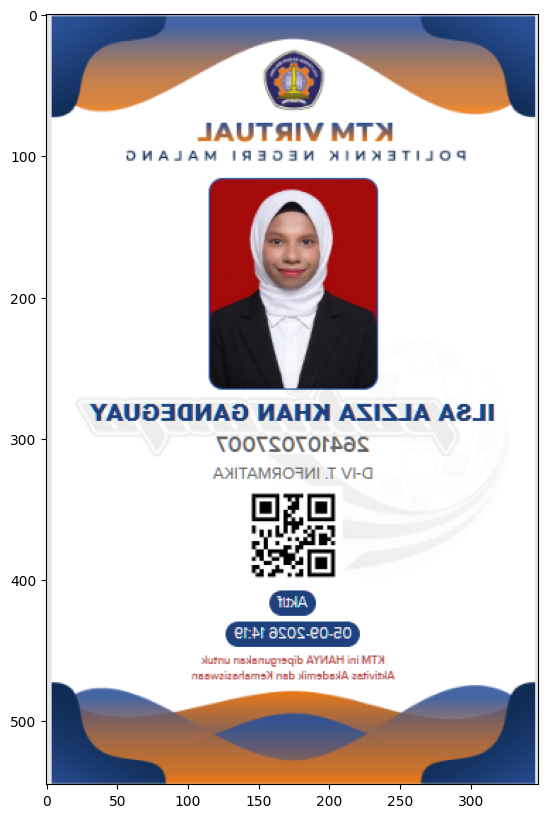

In [ ]:
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(1,1,1)
ax1.imshow(imgFlip)

Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16.

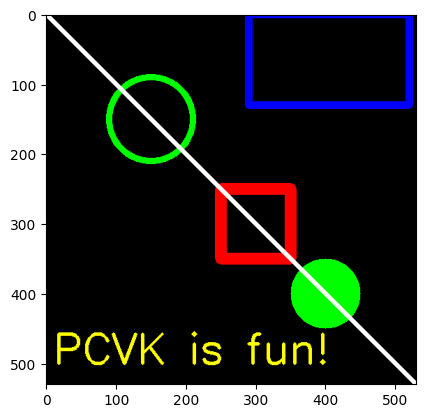

In [ ]:
black_img = np.zeros((530,530,3), dtype=np.int16)
plt.imshow(black_img)

#pt1
cv.rectangle(black_img, pt1=(290,0), pt2=(520,130), color=(0,0,255), thickness=10)
plt.imshow(black_img)

#pt2
cv.rectangle(black_img, pt1=(250,250), pt2=(350,350), color=(255,0,0), thickness=15)
plt.imshow(black_img)

#cc1
cv.circle(black_img, center=(150,150), radius=60, color=(0,255,0), thickness=8)
plt.imshow(black_img)

#cc2
cv.circle(black_img, center=(400,400), radius=50, color=(0,255,0), thickness=-1)
cv.line(black_img, pt1=(0,0), pt2=(530,530), color=(255,255,255), thickness=5)
plt.imshow(black_img)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2, color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

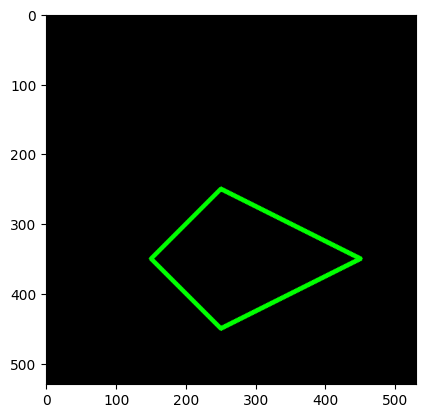

In [ ]:
black_img2 = np.zeros((530,530,3), dtype=np.int32)
plt.imshow(black_img2)

vertices = np.array([[150,350],[250,250],[450,350],[250,450]], dtype=np.int32)
pts = vertices.reshape((-1,1,2))
cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)
#

# **Pertanyaan Praktikum**

1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan
dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan
tersebut.

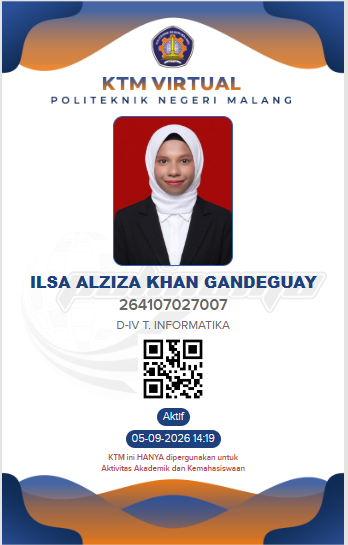

Nilai piksel pada koordinat (x=100, y=100):
OpenCV : [240 236 234]
Matplotlib menggunakan data yang sama : [240 236 234]


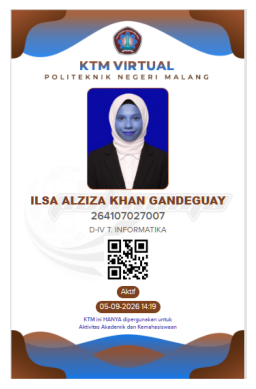

In [ ]:
#1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
cv2_imshow(img)

plt.axis("off")
plt.imshow(img)


# Mengambil satu piksel yang sama
y = 100
x = 100

print("Nilai piksel pada koordinat (x=100, y=100):")
print("OpenCV :", img[y, x])
print("Matplotlib menggunakan data yang sama :", img[y, x])

Jawaban:

Perbedaan citra yang dihasilkan dari cv2_imshow() dan plt.imshow() dikarenakan cv2_imshow() mengambil warna asli dari citra yang di input. Sedangkan plt.imshow() menampilkan citra dengan mengkonversinya ke GBR

2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya
berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

In [ ]:
#2 Membandingkan dtype, min(), max(), dan nbytes keduanya.

# Ukuran kanvas, misalnya 500 x 500 piksel
tinggi = 150
lebar  = 150

# Membuat kanvas hitam
canvas_int16 = np.zeros((tinggi, lebar), dtype=np.int16)
canvas_int32 = np.zeros((tinggi, lebar), dtype=np.int32)

# Membandingkan informasi keduanya
print("=== int16 ===")
print("dtype :", canvas_int16.dtype)
print("min   :", canvas_int16.min())
print("max   :", canvas_int16.max())
print("nbytes:", canvas_int16.nbytes)

print("\n=== int32 ===")
print("dtype :", canvas_int32.dtype)
print("min   :", canvas_int32.min())
print("max   :", canvas_int32.max())
print("nbytes:", canvas_int32.nbytes)


=== int16 ===
dtype : int16
min   : 0
max   : 0
nbytes: 45000

=== int32 ===
dtype : int32
min   : 0
max   : 0
nbytes: 90000


Jawaban:

Untuk ukuran tampilan, tidak terdapat perbedaan sama sekali karena int16 dan int32 mengambil ukuran canvas yang sama. Namun ukuran memori keduanya berbeda karena int16 menggunakan 16 bit yang berarti mempunyai 2 byte setiap elemennta dan int32 menggunakan 32 bit yang berarti menggunakan 4 byte untuk setiap elemennya. Jadi jika dihitung maka

Jumlah elemen 1nt16: 150 x 150 = 22.500

sehingga byte int16 menjadi 22.500 x 2 = 45.000 bytes

=========================================================================
Jumlah elemen 1nt32: 150 x 150 = 22.500

sehingga byte int32 menjadi 22.500 x 4 = 90.000 bytes

3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google
Colab?

Jawaban:

from google.colab.patches import cv2_imshow digunakan untuk mengimpor fungsi cv2_imshow() yang secara khusus disediakan oleh google colab sehingga dapat mengambil gambar dari openCV untuk ditampilkan pada saat run. Selanjutnya adalah mengapa kita tidak cv2.imshow() tidak dapat dipakai di Google Colab adalah karena cv2.imshow dirancang untuk membuka jendela GUI pada komputer, sedangkan Google Colab tidak berjalan sebagai software komputer yang mempunyai akses langsung pada GUI melainkan Google Colab ini berjalan hanya pada lingkungan server.

4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.

skimage      : [234 236 240 255]
OpenCV BGR    : [240 236 234]
OpenCV RGB    : [234 236 240]


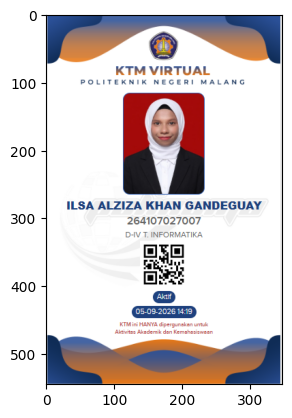

In [ ]:
#membaca gambar
img_skimage = io.imread("KTM.png")
# cv2_imshow(img) # This line was causing issues with img_cv, removed as it's not needed for the conversion

#menguba GBR ke RGB
img_cv_RGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img_cv_RGB)

#Koordinat pixel
y = 100
x = 100

print("skimage      :", img_skimage[y, x])
print("OpenCV BGR    :", img[y, x])
print("OpenCV RGB    :", img_cv_RGB[y, x])

Jawaban:

yang menghasilkan kanal sebenarnya adalah skimage.io.imread() karena fungsi ini membaca citra dalam urutan RGB dan juga cv2.cvtColor(img, cv2.COLOR_BGR2RGB) yang mengubah warna citra yang dibaca oleh cv2 yaitu BGR menjadi RGB. sedangkan kanal yang tertukar dihasilkan oleh cv2.imread() karena fungsi tersebut membaca citra dalam urutan BGR.

5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.

Sebelum ditampilkan: (545, 348, 3)


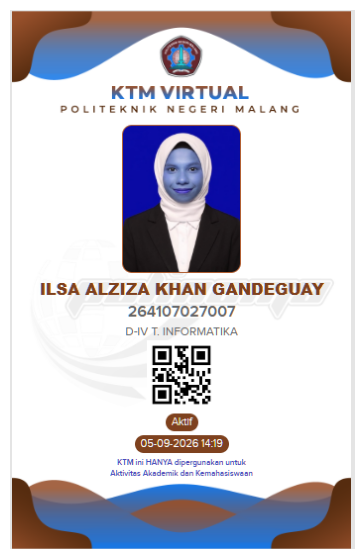

Setelah ditampilkan : (545, 348, 3)


In [ ]:
print("Sebelum ditampilkan:", img.shape)

plt.figure(figsize=(5, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

print("Setelah ditampilkan :", img.shape)

jawaban:

ukuran img.shape setelah ukuran figsize enjadi lebih besar adalah sama.  Hal ini dikarenakan figsize hanya mengubah ukuran tampilan (display), bukan ukuran sebenarnya dari data citra.